In [89]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Data import

In [92]:
# Import data
df = pd.read_csv("data/dataset.csv")
df["geometry"] = df["geometry"].apply(wkt.loads)
df_input = gpd.GeoDataFrame(df, geometry="geometry")

# variables
variables = ["ELC_cap", "GDP_cap", "COMP_emp", "POP_density", "HDD", "CDD"]

In [94]:
# Compute summary statistics of the variable
summary_stats = pd.DataFrame()
tmp = df_input[variables].copy()

summary_stats['Mean'] = tmp[variables].mean(numeric_only=True).round(2)
summary_stats['Std. Dev.'] = tmp[variables].std(numeric_only=True).round(2)
summary_stats['1st Quartile'] = tmp[variables].quantile(0.25, numeric_only=True).round(2)
summary_stats['Median'] = tmp[variables].median(numeric_only=True).round(2)
summary_stats['3rd Quartile'] = tmp[variables].quantile(0.75, numeric_only=True).round(2)

print(summary_stats)

                Mean  Std. Dev.  1st Quartile   Median  3rd Quartile
ELC_cap         6.44       4.96          3.95     5.24          6.77
GDP_cap        36.47      22.29         25.52    32.80         42.02
COMP_emp       35.93      18.03         19.46    39.07         46.37
POP_density   511.20    1370.61         76.02   134.61        329.84
HDD          2684.93     959.68       2213.00  2601.94       3104.50
CDD            80.89     141.93          3.14    19.50         75.25


# NUTS Mann-Whitney test

In [97]:
# Mann–Whitney U test
from scipy.stats import mannwhitneyu

for var in variables:
    group1 = df_input[df_input["LEVEL"] == 1][var].dropna()
    group2 = df_input[df_input["LEVEL"] == 2][var].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"{var}: U={stat:.0f}, p-value={p:.3f}")

ELC_cap: U=10569, p-value=0.591
GDP_cap: U=11387, p-value=0.195
COMP_emp: U=11355, p-value=0.205
POP_density: U=11415, p-value=0.186
HDD: U=12407, p-value=0.025
CDD: U=11092, p-value=0.306


# VIF

In [86]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

years = [2021, 2022, 2023]

vif_list = []

for year in years:
    tmp = df_input[df_input["YEAR"] == year].copy()

    X = tmp[[v for v in variables if v != "ELC_cap"]].dropna().copy()
    X = add_constant(X)

    vif_data = pd.DataFrame({
        "Variable": X.columns,
        str(year): [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    vif_list.append(vif_data)

# generate recap table 
vif_final = vif_list[0]
for df in vif_list[1:]:
    vif_final = vif_final.merge(df, on="Variable", how="outer")

vif_final = vif_final.round(2)
vif_final = vif_final[vif_final["Variable"] != "const"].reset_index(drop=True)
print(vif_final)


      Variable  2021  2022  2023
0          CDD  1.65  1.81  1.65
1     COMP_emp  2.81  1.53  1.50
2      GDP_cap  3.13  1.93  1.88
3          HDD  1.61  1.80  1.68
4  POP_density  1.31  1.51  1.52


# Import additional countries (plotting purpose)

In [26]:
# Import uncovered NUTS country shape (NUTS0)
uncovered_countries = ['AL', 'RS', 'IS', 'LI', 'ME', 'MK', 'TR', 'EL',
                       'BG', 'RO', 'BY', 'UA']

all_nuts = gpd.read_file('./data/NUTS_RG_20M_2021_3035.gpkg')

tmp = all_nuts[all_nuts['LEVL_CODE'] == 0].copy()
tmp = tmp[tmp['CNTR_CODE'].isin(uncovered_countries)].copy()
tmp = tmp[['geometry', 'NUTS_ID']].rename(columns={'NUTS_ID': 'NUTS'})
tmp = gpd.GeoDataFrame(tmp, geometry='geometry', crs=all_nuts.crs)

# Import extra European countries
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

extra_list = ['Belarus', 'Ukraine', 'Moldova', 'Bosnia and Herzegovina', 'Kosovo', 'Russia']
others = world[world['ADMIN'].isin(extra_list)].copy()

code_map = {
    'Belarus': 'BLR',
    'Ukraine': 'UKR',
    'Moldova': 'MDA',
    'Bosnia and Herzegovina': 'BIH',
    'Kosovo': 'KSV',
    'Russia': 'RUS'
}

others['NUTS'] = others['ADMIN'].map(code_map)
others = others[['geometry', 'NUTS']].copy()
others = gpd.GeoDataFrame(others, geometry='geometry', crs=world.crs)

# Reproject csr
others = others.to_crs(tmp.crs)

# Concatenate
df_additional = pd.concat([tmp, others], ignore_index=True)
df_additional_gdf = gpd.GeoDataFrame(df_additional, geometry='geometry', crs=tmp.crs)

# Final coverage

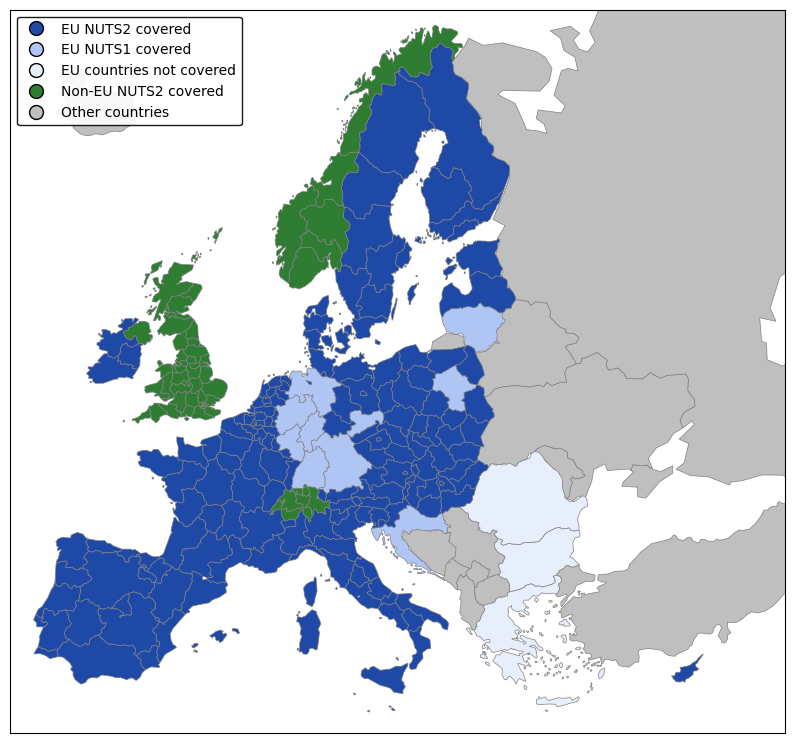

In [29]:
# Covered groups
covered_gdf = df_input[['NUTS', 'LEVEL', 'geometry']].drop_duplicates().copy()
covered_gdf = gpd.GeoDataFrame(covered_gdf, geometry='geometry', crs=df_input.crs)
covered_gdf = covered_gdf.set_crs(df_additional_gdf.crs)
covered_gdf['country'] = covered_gdf['NUTS'].str[:2]

non_eu_special = ['NO', 'UK', 'CH']
eu_not_covered = ['BG', 'EL', 'RO']

mask_nuts2_non_eu = (covered_gdf['LEVEL'] == 2) & (covered_gdf['country'].isin(non_eu_special))
mask_nuts2_eu = (covered_gdf['LEVEL'] == 2) & (~covered_gdf['country'].isin(non_eu_special))
mask_nuts1_eu = (covered_gdf['LEVEL'] == 1) & (~covered_gdf['country'].isin(non_eu_special))

gdf_nuts2_eu = covered_gdf[mask_nuts2_eu].copy()
gdf_nuts1_eu = covered_gdf[mask_nuts1_eu].copy()
gdf_nuts2_non_eu = covered_gdf[mask_nuts2_non_eu].copy()


# Not Covered groups
additional_gdf = df_additional_gdf.copy()
additional_gdf = gpd.GeoDataFrame(additional_gdf, geometry='geometry', crs=df_additional_gdf.crs)

if additional_gdf.crs != covered_gdf.crs:
    additional_gdf = additional_gdf.to_crs(covered_gdf.crs)

gdf_eu_not_covered = additional_gdf[additional_gdf['NUTS'].isin(eu_not_covered)].copy()
gdf_other_countries = additional_gdf[~additional_gdf['NUTS'].isin(eu_not_covered)].copy()


# Colors
color_nuts2_eu = '#1F49A7'     
color_nuts1_eu = '#AFC6F5'     
color_eu_not_cov = '#E8EFFC'   
color_nuts2_non_eu = '#2E7D32' 
color_other = '#BFBFBF'


# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_other_countries.plot(ax=ax, color=color_other, edgecolor='0.5', linewidth=0.5)
gdf_eu_not_covered.plot(ax=ax, color=color_eu_not_cov, edgecolor='0.5', linewidth=0.5,)
gdf_nuts1_eu.plot(ax=ax, color=color_nuts1_eu, edgecolor='0.5', linewidth=0.5)
gdf_nuts2_eu.plot(ax=ax, color=color_nuts2_eu, edgecolor='0.5', linewidth=0.5)
gdf_nuts2_non_eu.plot(ax=ax, color=color_nuts2_non_eu, edgecolor='0.5', linewidth=0.5)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='black', label='EU NUTS2 covered',
           markerfacecolor=color_nuts2_eu, markersize=10, linestyle='None'),
    Line2D([0], [0], marker='o', color='black', label='EU NUTS1 covered',
           markerfacecolor=color_nuts1_eu, markersize=10, linestyle='None'),
    Line2D([0], [0], marker='o', color='black', label='EU countries not covered',
           markerfacecolor=color_eu_not_cov, markersize=10, linestyle='None'),
    Line2D([0], [0], marker='o', color='black', label='Non-EU NUTS2 covered',
           markerfacecolor=color_nuts2_non_eu, markersize=10, linestyle='None'),
    Line2D([0], [0], marker='o', color='black', label='Other countries',
           markerfacecolor=color_other, markersize=10, linestyle='None')
]

ax.legend(handles=legend_elements, loc='upper left',
          frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')
# Axis
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(2500000, 7000000)
ax.set_ylim(1300000, 5500000)
ax.ticklabel_format(style='plain', axis='both')

# Save
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/final_coverage_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot variables

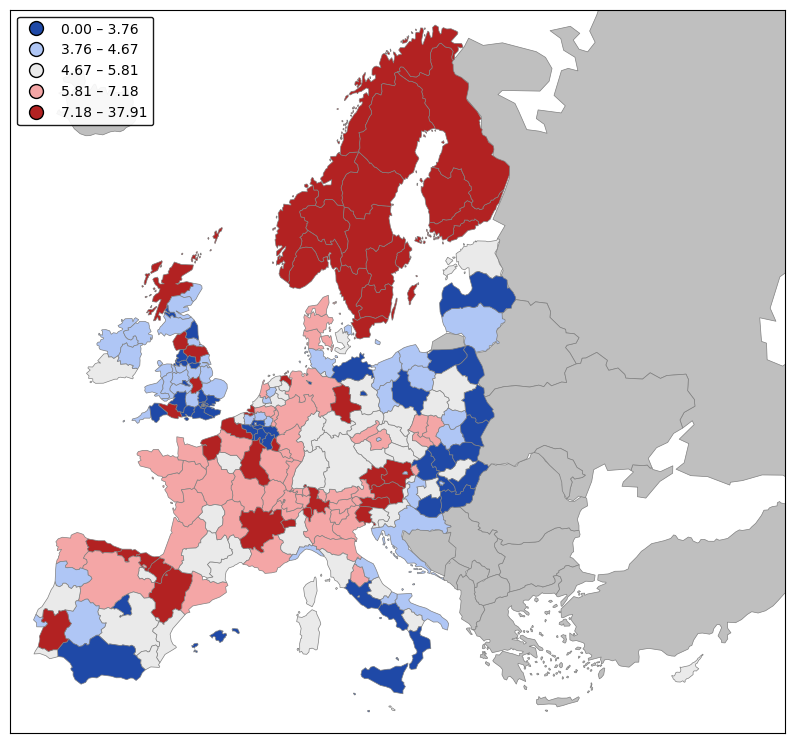

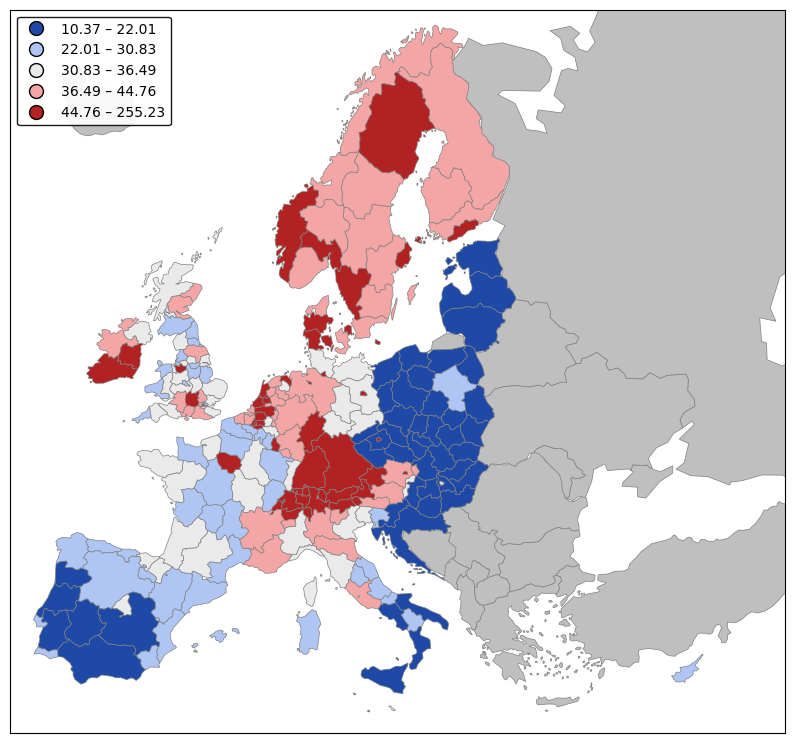

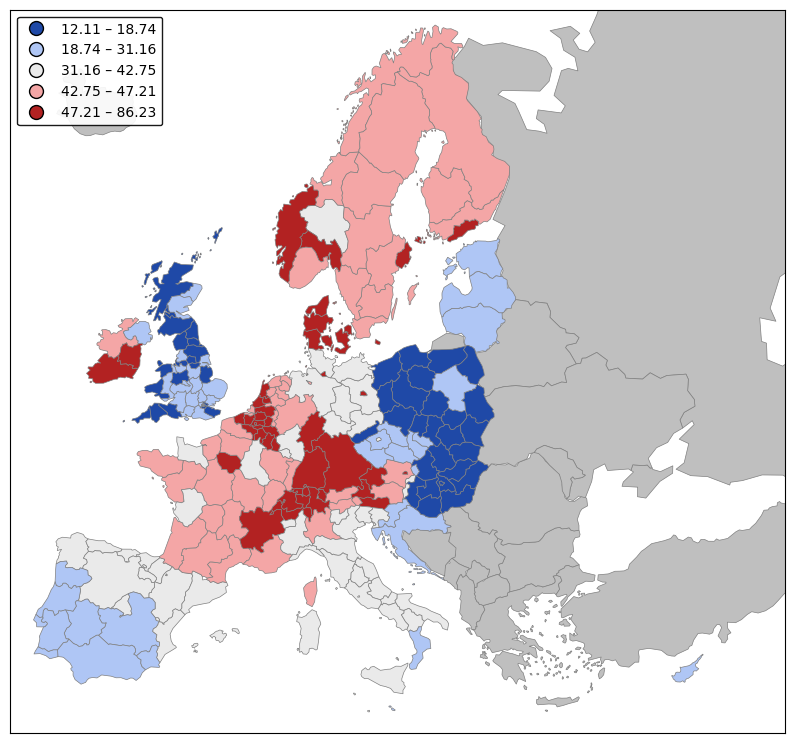

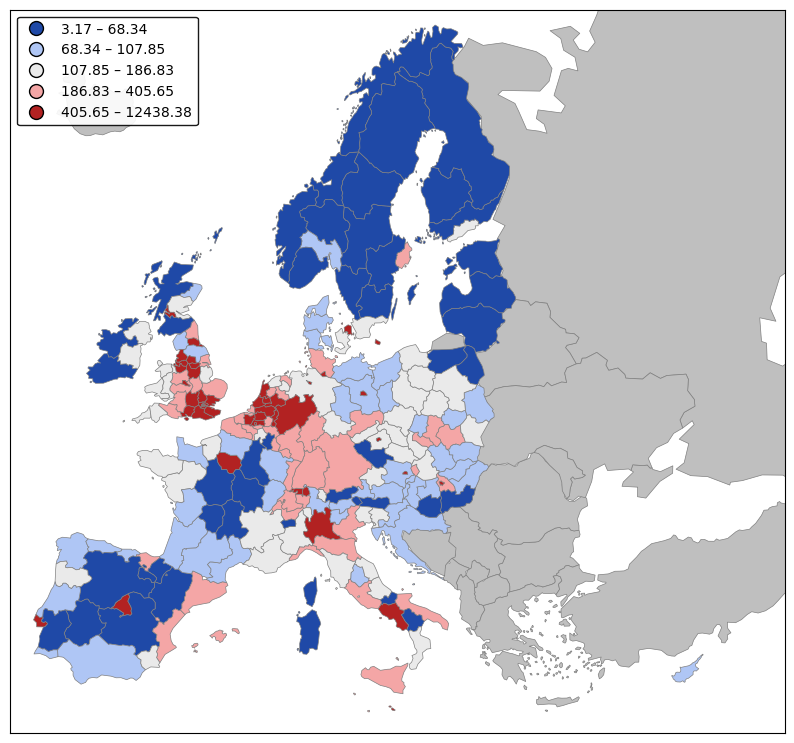

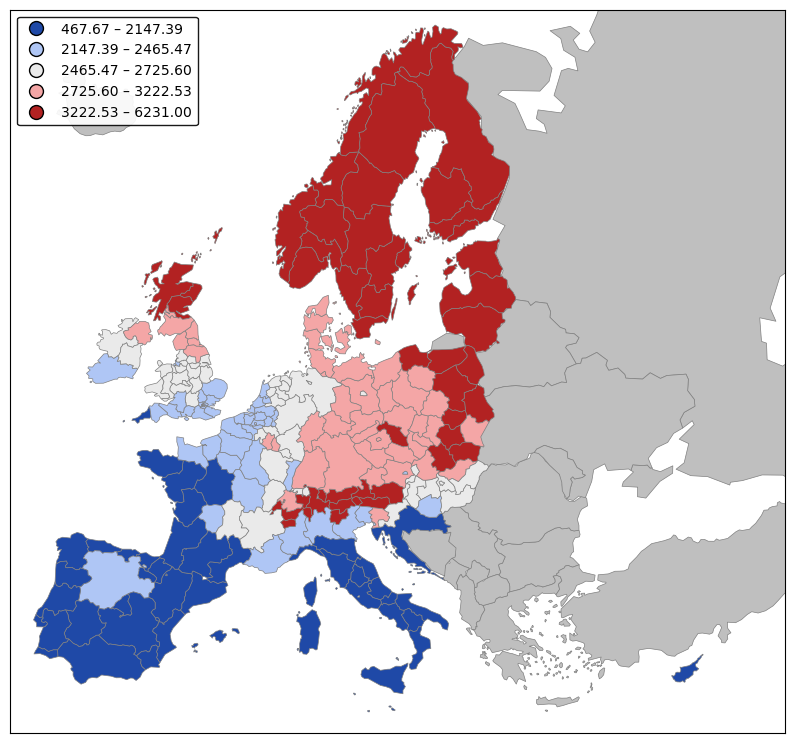

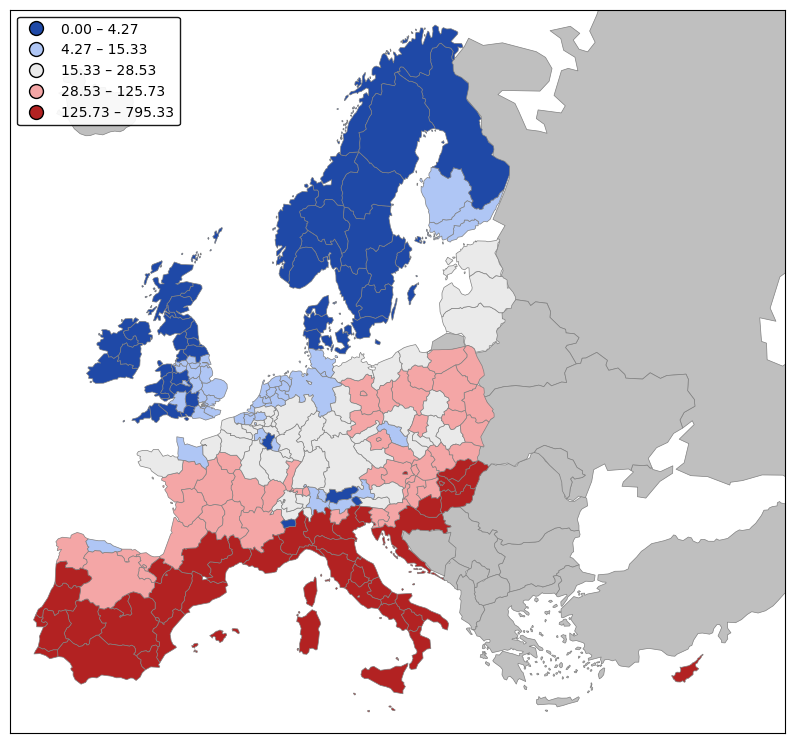

In [31]:
# Plot labels
indicator_map = {
    'ELC_cap': 'ELC per capita',
    'GDP_cap': 'GDP per capita',
    'COMP_emp': 'Compensation per employee',
    'POP_density': 'Population density',
    'CDD': 'CDD',
    'HDD': 'HDD'
}

os.makedirs('plots/variables', exist_ok=True)


# Map layers
covered_gdf = df_input[['NUTS', 'LEVEL', 'geometry']].drop_duplicates().copy()
covered_gdf = gpd.GeoDataFrame(covered_gdf, geometry='geometry', crs=df_input.crs)
covered_gdf = covered_gdf.set_crs(df_additional_gdf.crs)

additional_gdf = df_additional_gdf.copy()
additional_gdf = gpd.GeoDataFrame(additional_gdf, geometry='geometry', crs=df_additional_gdf.crs)

if additional_gdf.crs != covered_gdf.crs:
    additional_gdf = additional_gdf.to_crs(covered_gdf.crs)

background_gdf = additional_gdf.copy()


# Mean value over the period
grouped_df = df_input.groupby('NUTS')[variables].mean().reset_index()

geom_df = df_input[['NUTS', 'geometry']].drop_duplicates().copy()
merged = pd.merge(grouped_df, geom_df, on='NUTS', how='left')

grouped_gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs=covered_gdf.crs)
grouped_gdf = grouped_gdf.set_crs(covered_gdf.crs)


# Colors
color_background = '#BFBFBF'
colors = ['#1F49A7', '#AFC6F5', '#EAEAEA', '#F4A6A6', '#B22222']


# Plot 
for indicator in variables:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    plot_gdf = grouped_gdf[grouped_gdf[indicator].notna()].copy()

    # quantile classification
    categories, bins = pd.qcut(
        plot_gdf[indicator],
        q=5, 
        labels=False,
        retbins=True,
        duplicates='drop'
    )

    plot_gdf['category'] = categories
    n_classes = len(bins) - 1
    class_colors = colors[:n_classes]
    plot_gdf['color'] = plot_gdf['category'].map(dict(enumerate(class_colors)))

    # Add background
    background_gdf.plot(
        ax=ax,
        color=color_background,
        linewidth=0.5,
        edgecolor='0.5'
    )

    # Variable values
    plot_gdf.plot(
        ax=ax,
        color=plot_gdf['color'],
        linewidth=0.5,
        edgecolor='0.5'
    )

    # Legend
    legend_elements = []
    for i in range(n_classes):
        legend_elements.append(
            Line2D(
                [0], [0],
                color='w',
                marker='o',
                label=f"{bins[i]:.2f} – {bins[i+1]:.2f}",
                markerfacecolor=class_colors[i],
                markeredgecolor='black',
                markersize=10,
                linestyle='None'
            )
        )

    ax.legend(
        handles=legend_elements,
        loc='upper left',
        frameon=True,
        facecolor='white',
        framealpha=0.9,
        edgecolor='black'
    )

    # Axis
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(2500000, 7000000)
    ax.set_ylim(1300000, 5500000)
    ax.ticklabel_format(style='plain', axis='both')

    # Save
    plt.savefig(
        f"plots/variables/average_{indicator_map[indicator]}.png",
        dpi=300,
        bbox_inches='tight'
    )
    #plt.show()

# HYPOTHESIS 1

## Global Moran I

In [33]:
import libpysal
from libpysal.weights import Queen, KNN
from esda.moran import Moran

# Compute average ELC per capita over the three years
average_ELC = df_input.groupby(['NUTS', 'geometry'])['ELC_cap'].mean().reset_index()

# Remove island for Queen version
island_regions = ['CY00', 'ES53', 'FI20', 'FRM0', 'ITG1', 'ITG2', 'MT00']
average_ELC_filtered = average_ELC[~average_ELC['NUTS'].isin(island_regions)].reset_index(drop=True)

/Users/gianpietro/opt/anaconda3/envs/pysal_env/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  warnings.warn(message)


2 0.553 0.001
3 0.557 0.001
4 0.568 0.001
5 0.528 0.001
6 0.494 0.001
7 0.484 0.001
8 0.472 0.001
9 0.448 0.001
10 0.442 0.001
11 0.423 0.001
12 0.418 0.001
13 0.412 0.001
14 0.4 0.001
15 0.387 0.001


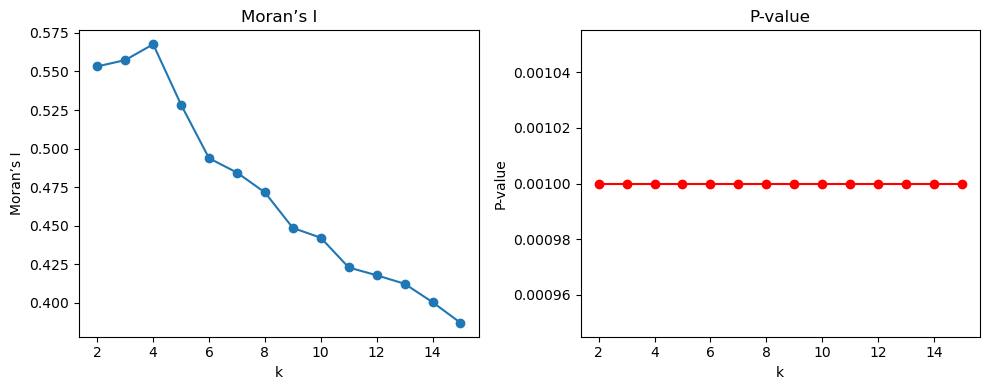

In [35]:
# Look for best K for KNN
np.random.seed(42)
k_range = range(2, 16)
morans_i = []
p_values = []

for k in k_range:
    w = KNN.from_dataframe(average_ELC, k=k)
    w.transform = 'r'
    moran = Moran(average_ELC['ELC_cap'], w)
    morans_i.append(moran.I)
    p_values.append(moran.p_sim)
    print(k,round(moran.I,3),round(moran.p_sim,3))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, morans_i, marker='o')
plt.title("Moran’s I")
plt.xlabel("k")
plt.ylabel("Moran’s I")

plt.subplot(1, 2, 2)
plt.plot(k_range, p_values, marker='o', color='red')
plt.title("P-value")
plt.xlabel("k")
plt.ylabel("P-value")

plt.tight_layout()
plt.show()

In [37]:
# Queen Weights
w_queen = libpysal.weights.Queen.from_dataframe(average_ELC_filtered, use_index=False)
w_queen.transform = 'r'
moran_queen = Moran(average_ELC_filtered['ELC_cap'], w_queen)
print("Queen:")
print(f"Moran’s I: {moran_queen.I:.3f}, P-value: {moran_queen.p_sim:.3f}")

# KNN Weights
best_k = 4
w_knn = KNN.from_dataframe(average_ELC, k=best_k)
w_knn.transform = 'r'
moran_knn = Moran(average_ELC['ELC_cap'], w_knn)
print("\nKNN:")
print(f"Moran’s I: {moran_knn.I:.3f}, P-value: {moran_knn.p_sim:.3f}")

Queen:
Moran’s I: 0.639, P-value: 0.001

KNN:
Moran’s I: 0.568, P-value: 0.001


/Users/gianpietro/opt/anaconda3/envs/pysal_env/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  warnings.warn(message)


## LISA

/Users/gianpietro/opt/anaconda3/envs/pysal_env/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
  warnings.warn(message)


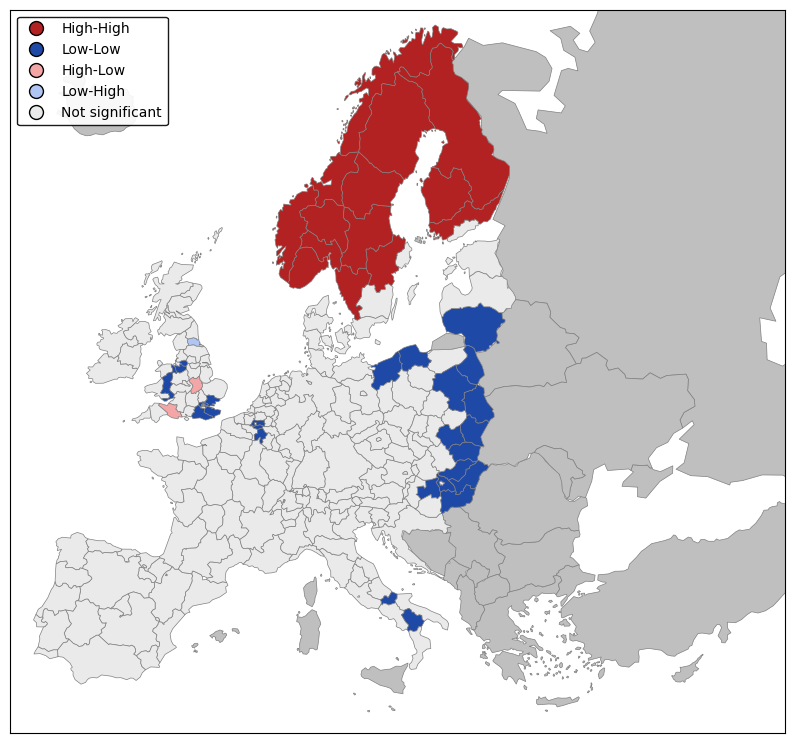


LISA Cluster Summary (Queen)
LISA_cluster
Not significant    180
Low-Low             27
High-High           14
High-Low             3
Low-High             1
Name: count, dtype: int64


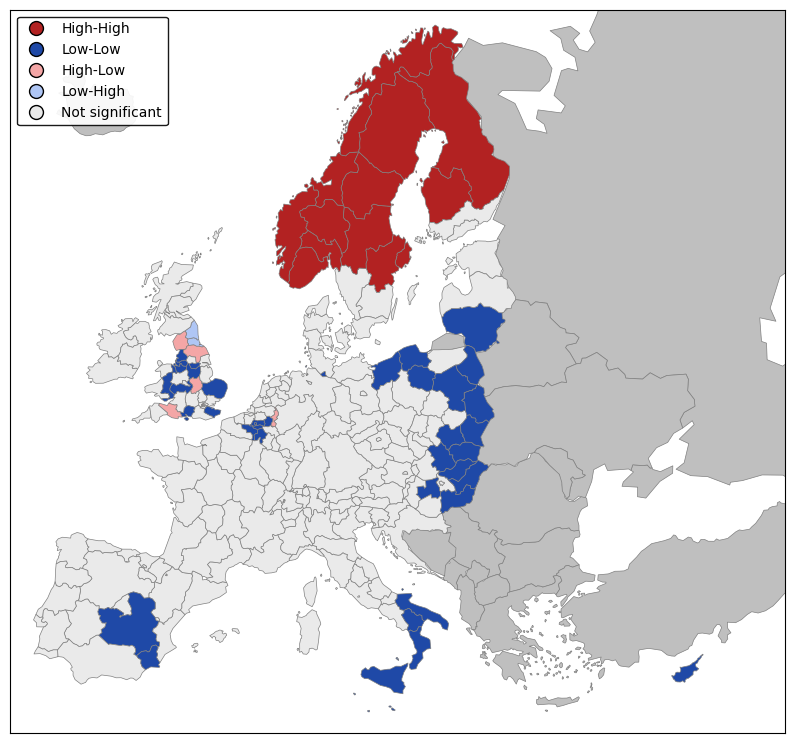


LISA Cluster Summary (KNN, k=4)
LISA_cluster
Not significant    170
Low-Low             41
High-High           13
High-Low             6
Low-High             2
Name: count, dtype: int64


In [40]:
from esda.moran import Moran_Local
np.random.seed(42)
os.makedirs("plots/LISA", exist_ok=True)


# Average ELC over the period
grouped_df = df_input.groupby('NUTS')[['ELC_cap']].mean().reset_index()
geom_df = df_input[['NUTS', 'geometry']].drop_duplicates().copy()
merged = pd.merge(grouped_df, geom_df, on='NUTS', how='left')

gdf_full = gpd.GeoDataFrame(merged, geometry='geometry', crs=covered_gdf.crs)
gdf_full = gdf_full.set_crs(covered_gdf.crs)


# Colors
cluster_colors = {
    'High-High': '#B22222',        # dark red
    'Low-Low': '#1F49A7',          # dark blue
    'High-Low': '#F4A6A6',         # light red
    'Low-High': '#AFC6F5',         # light blue
    'Not significant': '#EAEAEA',  # light grey
    'Not in model': '#BFBFBF'      # dark grey
}


# Remove islands
islands_gdf = gdf_full[gdf_full['NUTS'].isin(island_regions)].copy().reset_index(drop=True)
gdf_no_islands = gdf_full[~gdf_full['NUTS'].isin(island_regions)].copy().reset_index(drop=True)

# Lisa function
def compute_lisa(gdf, w):
    lisa = Moran_Local(gdf['ELC_cap'], w)

    cluster_labels = np.array(['Not significant'] * len(gdf), dtype=object)
    significant = lisa.p_sim < 0.05

    cluster_labels[significant & (lisa.q == 1)] = 'High-High'
    cluster_labels[significant & (lisa.q == 2)] = 'Low-High'
    cluster_labels[significant & (lisa.q == 3)] = 'Low-Low'
    cluster_labels[significant & (lisa.q == 4)] = 'High-Low'

    gdf_out = gdf.copy()
    gdf_out['LISA_cluster'] = cluster_labels
    gdf_out['color'] = gdf_out['LISA_cluster'].map(cluster_colors)

    return gdf_out, lisa

# Plot Lisa
def plot_lisa(gdf_plot, islands_gdf=None, filename='LISA.png', include_islands=False):

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Background
    background_gdf.plot(
        ax=ax,
        color='#BFBFBF',
        linewidth=0.5,
        edgecolor='0.5'
    )

    # Main regions
    gdf_plot.plot(
        ax=ax,
        color=gdf_plot['color'],
        linewidth=0.5,
        edgecolor='0.5'
    )

    # Islands (only for Queen)
    if include_islands and islands_gdf is not None and len(islands_gdf) > 0:
        islands_plot = islands_gdf.copy()
        islands_plot['color'] = cluster_colors['Not in model']
        islands_plot.plot(
            ax=ax,
            color=islands_plot['color'],
            linewidth=0.5,
            edgecolor='0.5'
        )

    # Legend
    legend_order = ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'Not significant']
    

    legend_elements = [
        Line2D(
            [0], [0],
            color='w',
            marker='o',
            label=lab,
            markerfacecolor=cluster_colors[lab],
            markeredgecolor='black',
            markersize=10,
            linestyle='None'
        )
        for lab in legend_order
    ]

    ax.legend(
        handles=legend_elements,
        loc='upper left',
        frameon=True,
        facecolor='white',
        framealpha=0.9,
        edgecolor='black'
    )

    # Axis
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(2500000, 7000000)
    ax.set_ylim(1300000, 5500000)
    ax.ticklabel_format(style='plain', axis='both')

    plt.savefig(f"plots/LISA/{filename}", dpi=300, bbox_inches='tight')
    plt.show()

# Lisa with Queen
def run_lisa_queen(gdf_no_islands, islands_gdf):
    w = Queen.from_dataframe(gdf_no_islands, use_index=False)
    w.transform = 'r'

    gdf_lisa, lisa = compute_lisa(gdf_no_islands, w)

    plot_lisa(gdf_lisa, islands_gdf=islands_gdf, filename='LISA_ELC_queen.png', include_islands=True)

    print("\nLISA Cluster Summary (Queen)")
    print(gdf_lisa['LISA_cluster'].value_counts())

    return gdf_lisa, lisa

# Lisa with KNN
def run_lisa_knn(gdf_full, k=best_k):
    w = KNN.from_dataframe(gdf_full, k=k)
    w.transform = 'r'

    gdf_lisa, lisa = compute_lisa(gdf_full, w)

    plot_lisa(gdf_lisa, filename=f'LISA_ELC_knn_k{k}.png', include_islands=False)

    print(f"\nLISA Cluster Summary (KNN, k={k})")
    print(gdf_lisa['LISA_cluster'].value_counts())

    return gdf_lisa, lisa


queen_gdf, lisa_queen = run_lisa_queen(gdf_no_islands, islands_gdf)
knn_gdf, lisa_knn = run_lisa_knn(gdf_full, k=4)

# HYPOTHESIS 2

## GWR model tuning

In [44]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# Kernels
kernels = ["gaussian", "exponential", "bisquare"]

df_by_year = {}
gwr_data_by_year = {}
gwr_bandwidths_by_year = {}
gwr_best_kernel_by_year = {}

for current_year in years:

    print("\n" + "=" * 50)
    print(f"GWR KERNEL SELECTION - {current_year}")
    print("=" * 50 + "\n")
   
    # Filter data for current year
    tmp = df_input[df_input["YEAR"] == current_year].copy()
    df_by_year[current_year] = tmp.copy()
  
    # Standardize 
    g_y = tmp["ELC_cap"].values.reshape((-1, 1))
    g_X = tmp[[v for v in variables if v != "ELC_cap"]].values

    g_X = (g_X - g_X.mean(axis=0)) / g_X.std(axis=0)
    g_y = (g_y - g_y.mean(axis=0)) / g_y.std(axis=0)
   
    # Coordinates
    centroids = tmp.geometry.centroid
    g_coords = list(zip(centroids.x, centroids.y))

    # Save data by year
    gwr_data_by_year[current_year] = {"g_y": g_y, "g_X": g_X, "g_coords": g_coords}

    # Kernel selection
    bw_results = {}
    resid_ss_results = {}
    aicc_results = {}
    adjr2_results = {}

    fitted_results_by_kernel = {}

    for kernel in kernels:

        selector = Sel_BW(g_coords, g_y, g_X, kernel=kernel, spherical=False, fixed=False)
        bw = selector.search()
        gwr_tmp_results = GWR(g_coords, g_y, g_X, bw=bw, kernel=kernel, spherical=False, fixed=False).fit()

        bw_results[kernel] = bw
        resid_ss_results[kernel] = round(gwr_tmp_results.resid_ss, 3)
        aicc_results[kernel] = round(gwr_tmp_results.aicc, 3)
        adjr2_results[kernel] = round(gwr_tmp_results.adj_R2, 3)

        fitted_results_by_kernel[kernel] = gwr_tmp_results

    print("\nBW:")
    print(bw_results)

    print("\nResidual Sum of Squares:")
    print(resid_ss_results)

    print("\nAICc:")
    print(aicc_results)

    print("\nAdjusted R²:")
    print(adjr2_results)

    # Select best kernel by adjusted R2
    best_kernel = max(adjr2_results, key=adjr2_results.get)
    best_bw = bw_results[best_kernel]

    print("\nBEST GWR SPECIFICATION")
    print(f"Best kernel: {best_kernel}")
    print(f"Best bandwidth: {best_bw}")

    gwr_best_kernel_by_year[current_year] = best_kernel
    gwr_bandwidths_by_year[current_year] = best_bw


GWR KERNEL SELECTION - 2021


BW:
{'gaussian': 54.0, 'exponential': 54.0, 'bisquare': 135.0}

Residual Sum of Squares:
{'gaussian': 91.875, 'exponential': 90.245, 'bisquare': 75.513}

AICc:
{'gaussian': 470.219, 'exponential': 473.309, 'bisquare': 440.57}

Adjusted R²:
{'gaussian': 0.583, 'exponential': 0.584, 'bisquare': 0.646}

BEST GWR SPECIFICATION
Best kernel: bisquare
Best bandwidth: 135.0

GWR KERNEL SELECTION - 2022


BW:
{'gaussian': 54.0, 'exponential': 54.0, 'bisquare': 131.0}

Residual Sum of Squares:
{'gaussian': 95.764, 'exponential': 93.328, 'bisquare': 79.721}

AICc:
{'gaussian': 479.643, 'exponential': 480.828, 'bisquare': 454.223}

Adjusted R²:
{'gaussian': 0.566, 'exponential': 0.57, 'bisquare': 0.626}

BEST GWR SPECIFICATION
Best kernel: bisquare
Best bandwidth: 131.0

GWR KERNEL SELECTION - 2023


BW:
{'gaussian': 54.0, 'exponential': 54.0, 'bisquare': 141.0}

Residual Sum of Squares:
{'gaussian': 88.863, 'exponential': 87.216, 'bisquare': 77.553}

AICc:
{'gaussia

## GWR model

In [47]:
gwr_results_by_year = {}
gwr_models_by_year = {}

for current_year in years:

    print("\n" + "-" * 50)
    print(f"FINAL GWR RESULTS - {current_year}")
    print("-" * 50 + "\n")

    # Retrieve standardized data for the year
    g_y = gwr_data_by_year[current_year]["g_y"]
    g_X = gwr_data_by_year[current_year]["g_X"]
    g_coords = gwr_data_by_year[current_year]["g_coords"]

    # Retrieve best kernel and bandwidth for the year
    best_kernel = gwr_best_kernel_by_year[current_year]
    best_bw = gwr_bandwidths_by_year[current_year]

    print(f"Best kernel: {best_kernel}")
    print(f"Best bandwidth: {best_bw}\n")

    # Run final best GWR model
    gwr_model = GWR(
        g_coords,
        g_y,
        g_X,
        bw=best_bw,
        kernel=best_kernel,
        spherical=False,
        fixed=False,
        hat_matrix=True
    )

    gwr_results = gwr_model.fit()

    print(gwr_results.summary())

    # Save final model and results
    gwr_models_by_year[current_year] = gwr_model
    gwr_results_by_year[current_year] = gwr_results



--------------------------------------------------
FINAL GWR RESULTS - 2021
--------------------------------------------------

Best kernel: bisquare
Best bandwidth: 135.0

Model type                                                         Gaussian
Number of observations:                                                 232
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            148.477
Log-likelihood:                                                    -277.422
AIC:                                                                566.845
AICc:                                                               569.345
BIC:                                                              -1082.485
R2:                                                                   0.360
Adj. R2:                               

## Non-stationarity tests

In [50]:
# F1 test
import statsmodels.api as sm
from scipy.stats import f

f1_results_by_year = {}

for current_year in years:

    print("\n" + "=" * 50)
    print(f"F1 TEST - {current_year}")
    print("=" * 50 + "\n")

    # Retrieve data and GWR results
    g_y = gwr_data_by_year[current_year]["g_y"]
    g_X = gwr_data_by_year[current_year]["g_X"]
    gwr_results = gwr_results_by_year[current_year]

    # OLS model
    ols_model = sm.OLS(g_y, sm.add_constant(g_X)).fit()
    RSS_OLS = np.sum(ols_model.resid ** 2)

    # GWR model
    RSS_GWR = np.sum(gwr_results.resid_response ** 2)

    # Sample size and number of regressors (excluding intercept)
    n = len(g_y)
    p = g_X.shape[1]

    # Hat matrix 
    L = gwr_results.S
    I = np.identity(n)

    # A = (I - L)'(I - L)
    A = (I - L).T @ (I - L)

    # d1 and d2 
    d1 = np.trace(A)
    d2 = np.trace(A @ A)

    # F1 statistic 
    F1 = (RSS_GWR / d1) / (RSS_OLS / (n - p - 1))

    # Approximate numerator and denominator df
    df1 = (d1 ** 2) / d2
    df2 = n - p - 1

    # LEFT-tail p-value -> small F1 favors GWR over OLS
    p_F1 = f.cdf(F1, df1, df2)

    alpha = 0.05
    if p_F1 < alpha:
        print("Reject H0: GWR fits significantly better than OLS.")
    else:
        print("Fail to reject H0: No significant improvement of GWR over OLS.")

    print("F1 =", round(F1, 3))
    print("p-value =", round(p_F1, 3))

    # Save results
    f1_results_by_year[current_year] = {
        "F1": F1,
        "p_value": p_F1,
        "df1": df1,
        "df2": df2,
        "RSS_OLS": RSS_OLS,
        "RSS_GWR": RSS_GWR,
        "d1": d1,
        "d2": d2
    }


F1 TEST - 2021

Reject H0: GWR fits significantly better than OLS.
F1 = 0.551
p-value = 0.0

F1 TEST - 2022

Reject H0: GWR fits significantly better than OLS.
F1 = 0.614
p-value = 0.0

F1 TEST - 2023

Reject H0: GWR fits significantly better than OLS.
F1 = 0.662
p-value = 0.001


In [52]:
# F3(k) test

f3_results_by_year = {}

for current_year in years:

    print("\n" + "=" * 50)
    print(f"F3(k) TEST - {current_year}")
    print("=" * 50 + "\n")

    # Retrieve data and GWR results
    g_y = gwr_data_by_year[current_year]["g_y"]
    g_X = gwr_data_by_year[current_year]["g_X"]
    gwr_results = gwr_results_by_year[current_year]

    F3_array = []
    p_F3_array = []

    # Sample size and number of regressors (excluding intercept)
    n = len(g_y)
    p = g_X.shape[1]

    # Design the matrix (including intercept)
    X_design = np.column_stack((np.ones(n), g_X))

    # Matrices for F3(k)
    I = np.identity(n)
    J = np.ones((n, n))

    # d1 and d2 from GWR residual structure
    L = gwr_results.S
    A = (I - L).T @ (I - L)
    d1 = np.trace(A)
    d2 = np.trace(A @ A)

    # GWR model
    RSS_GWR = np.sum(gwr_results.resid_response ** 2)

    # Unbiased residual variance estimator 
    sigma_hat_squared = RSS_GWR / d1

    # V_k^2 (sample variance of local coefficients for each explanatory variable)
    V_k_squared = np.zeros(p)
    for k in range(p):
        beta_ik = gwr_results.params[:, k + 1]   # skip intercept
        mean_beta_ik = np.mean(beta_ik)
        V_k_squared[k] = np.mean((beta_ik - mean_beta_ik) ** 2)

    # Loop over each variable
    for k in range(p):
        e_k = np.zeros((p + 1, 1))
        e_k[k + 1] = 1

        # Construct B matrix
        B = np.zeros((n, n))
        for i in range(n):
            W = np.diag(gwr_results.W[i])  # diagonal weighting matrix in i
            XtWX_inv = np.linalg.pinv(X_design.T @ W @ X_design)
            B[i, :] = (e_k.T @ XtWX_inv @ X_design.T @ W).flatten()

        # M = (1/n) * B' * (I - J/n) * B
        M = (1 / n) * B.T @ (I - (1 / n) * J) @ B

        # g1 and g2 
        g1 = np.trace(M)
        g2 = np.trace(M @ M)

        # F3(k)
        F3 = (V_k_squared[k] / g1) / sigma_hat_squared

        # Approximate F degrees of freedom
        df_num = (g1 ** 2) / g2
        df_den = (d1 ** 2) / d2

        # Large F3 supports spatial variability
        p_F3 = f.sf(F3, df_num, df_den)

        F3_array.append(F3)
        p_F3_array.append(p_F3)

    # Save results
    variable_names = [v for v in variables if v != "ELC_cap"]
    f3_results = pd.DataFrame({
        "Variable": variable_names,
        "F3_stat": F3_array,
        "p_value": p_F3_array
    })

    # Print results
    alpha = 0.05
    for _, row in f3_results.iterrows():
        if row["p_value"] < alpha:
            decision = "Reject H0: coefficients vary spatially"
        else:
            decision = "Fail to reject H0: coefficients likely constant"

        print(
            f"{row['Variable']}: "
            f"F3 = {row['F3_stat']:.3f}, "
            f"p = {row['p_value']:.3f} → {decision}"
        )

    f3_results_by_year[current_year] = f3_results


F3(k) TEST - 2021

GDP_cap: F3 = 1.819, p = 0.139 → Fail to reject H0: coefficients likely constant
COMP_emp: F3 = 4.454, p = 0.002 → Reject H0: coefficients vary spatially
POP_density: F3 = 1.237, p = 0.296 → Fail to reject H0: coefficients likely constant
HDD: F3 = 13.610, p = 0.000 → Reject H0: coefficients vary spatially
CDD: F3 = 7.101, p = 0.000 → Reject H0: coefficients vary spatially

F3(k) TEST - 2022

GDP_cap: F3 = 0.457, p = 0.724 → Fail to reject H0: coefficients likely constant
COMP_emp: F3 = 1.289, p = 0.278 → Fail to reject H0: coefficients likely constant
POP_density: F3 = 0.470, p = 0.695 → Fail to reject H0: coefficients likely constant
HDD: F3 = 8.796, p = 0.000 → Reject H0: coefficients vary spatially
CDD: F3 = 3.616, p = 0.008 → Reject H0: coefficients vary spatially

F3(k) TEST - 2023

GDP_cap: F3 = 0.370, p = 0.762 → Fail to reject H0: coefficients likely constant
COMP_emp: F3 = 1.421, p = 0.239 → Fail to reject H0: coefficients likely constant
POP_density: F3 =

## Condition numbers

In [55]:
# Check local collinearity

local_cn_results_by_year = {}

for current_year in years:

    print("\n" + "=" * 50)
    print(f"LOCAL CONDITION NUMBERS - {current_year}")
    print("=" * 50 + "\n")

    # Retrieve data and GWR results
    tmp = df_by_year[current_year]
    gwr_results = gwr_results_by_year[current_year]

    # Check local collinearity
    lc = gwr_results.local_collinearity()
    local_cn = lc[2]

    n = len(tmp["NUTS"].unique())

    n_cn_30 = np.sum(local_cn > 30)
    pct_cn_30 = round(n_cn_30 / n * 100, 2)

    print("CN > 30:", n_cn_30, pct_cn_30)

    # Save results
    local_cn_results_by_year[current_year] = {
        "local_cn": local_cn,
        "n_cn_30": n_cn_30,
        "pct_cn_30": pct_cn_30
    }


LOCAL CONDITION NUMBERS - 2021

CN > 30: 55 23.71

LOCAL CONDITION NUMBERS - 2022

CN > 30: 8 3.45

LOCAL CONDITION NUMBERS - 2023

CN > 30: 13 5.6


# HYPOTHESIS 3

## MGWR model

In [59]:
from mgwr.gwr import MGWR
from mgwr.sel_bw import Sel_BW

mgwr_results_by_year = {}
mgwr_models_by_year = {}
mgwr_selectors_by_year = {}
mgwr_bandwidths_by_year = {}
df_by_year = {}

for current_year in years:

    print("\n" + "=" * 50)
    print(f"MGWR RESULTS - {current_year}")
    print("=" * 50 + "\n")

    # Filter data for current year
    tmp = df_input[df_input['YEAR']==current_year].copy()
    df_by_year[current_year] = tmp.copy()

    # Standardize
    g_y = tmp['ELC_cap'].values.reshape((-1,1))
    g_X = tmp[[v for v in variables if v != "ELC_cap"]].values
    
    g_X = (g_X - g_X.mean(axis=0)) / g_X.std(axis=0)
    g_y = (g_y - g_y.mean(axis=0)) / g_y.std(axis=0)
    
    # Coodridnates
    centroids = tmp.geometry.centroid
    g_coords = list(zip(centroids.x, centroids.y))

    # Set my seed
    np.random.seed(42)

    # MGWR selector
    selector = Sel_BW(g_coords, g_y, g_X, multi=True, spherical=False)
    bw = selector.search()

    # MGWR
    mgwr_model = MGWR(g_coords, g_y, g_X, selector=selector, spherical=False)
    mgwr_results = mgwr_model.fit()

    # Print summary
    print(mgwr_results.summary())

    # Save results
    mgwr_results_by_year[current_year] = mgwr_results
    mgwr_models_by_year[current_year] = mgwr_model
    mgwr_selectors_by_year[current_year] = selector
    mgwr_bandwidths_by_year[current_year] = bw


MGWR RESULTS - 2021

Model type                                                         Gaussian
Number of observations:                                                 232
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            148.477
Log-likelihood:                                                    -277.422
AIC:                                                                566.845
AICc:                                                               569.345
BIC:                                                              -1082.485
R2:                                                                   0.360
Adj. R2:                                                              0.346

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ------

# HYPOTHESIS 4

##  KMeans

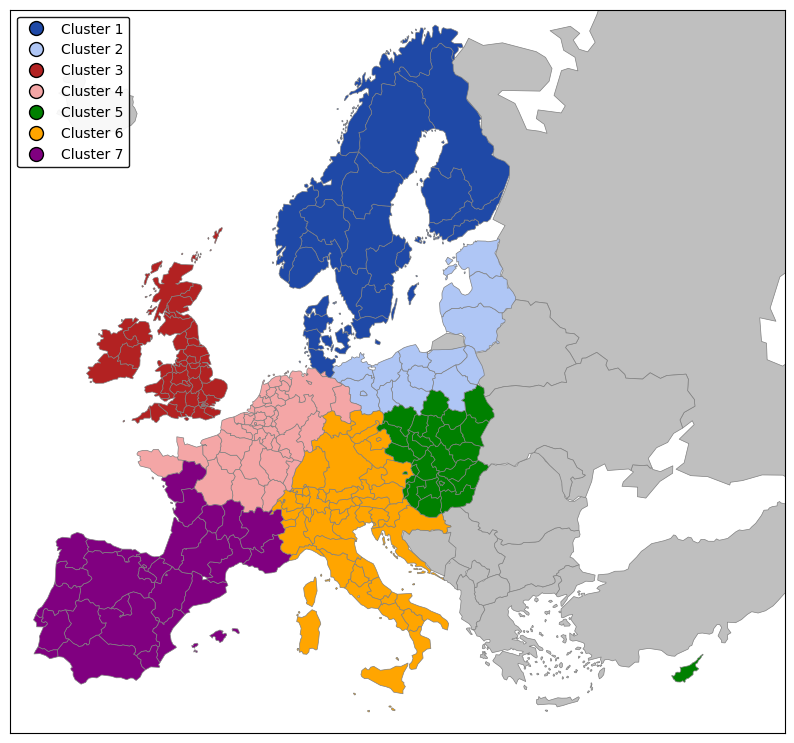


SILHOUETTE SCORES

k = 2: 0.367
k = 3: 0.433
k = 4: 0.452
k = 5: 0.461
k = 6: 0.467
k = 7: 0.475
k = 8: 0.452
k = 9: 0.460
k = 10: 0.455
k = 11: 0.452
k = 12: 0.457
k = 13: 0.460
k = 14: 0.444
k = 15: 0.432

AVERAGE COEFFICIENTS PER CLUSTER

           GDP_cap  COMP_emp  POP_density    HDD    CDD
Cluster 1    0.163    -0.023       -0.086  1.137  0.241
Cluster 2    0.169    -0.012       -0.084  0.441  0.221
Cluster 3    0.140    -0.071       -0.085  0.568  0.124
Cluster 4    0.150    -0.047       -0.085  0.148  0.098
Cluster 5    0.175    -0.007       -0.083  0.118  0.004
Cluster 6    0.163    -0.022       -0.085  0.081 -0.048
Cluster 7    0.146    -0.045       -0.087 -0.093 -0.132


In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Function to find best k
def choose_k_by_silhouette(X, range_n_clusters=range(2, 16)):
    scores = {}

    for k in range_n_clusters:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X)
        scores[k] = silhouette_score(X, labels)

    best_k = max(scores, key=scores.get)

    return best_k, scores


# Build average MGWR coefficients across years
def build_average_params_df(
    df_by_year,
    mgwr_results_by_year,
    full_varnames,
    years
):
    params_list = []

    for year in years:
        df_year = df_by_year[year].copy()
        mgwr_results = mgwr_results_by_year[year]

        params_df_year = pd.DataFrame(
            mgwr_results.params,
            columns=full_varnames
        )

        params_df_year["NUTS"] = df_year["NUTS"].values
        params_df_year["geometry"] = df_year["geometry"].values
        params_df_year["year"] = year

        params_list.append(params_df_year)

    params_all = pd.concat(params_list, ignore_index=True)

    # Average coefficients by NUTS
    params_avg = (
        params_all
        .groupby("NUTS")[full_varnames]
        .mean()
        .reset_index()
    )

    # Keep one geometry per NUTS
    geometry_df = (
        params_all[["NUTS", "geometry"]]
        .drop_duplicates("NUTS")
    )

    params_avg = params_avg.merge(
        geometry_df,
        on="NUTS",
        how="left"
    )

    return params_avg


# KMeans clustering function on average coefficients
def run_clustering(
    params_df,
    df_crs,
    cluster_variables,
    n_clusters=None,
    plot_filename="./plots/clusters/MGWR_KMeans_clusters_average.png"
):
    os.makedirs("./plots/clusters", exist_ok=True)

    # Scale selected coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(params_df[cluster_variables])

    # Choose k if not provided
    if n_clusters is None:
        n_clusters, silhouette_scores = choose_k_by_silhouette(X_scaled)
    else:
        silhouette_scores = None

    # Run KMeans
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    params_df = params_df.copy()
    params_df["cluster_raw"] = kmeans.fit_predict(X_scaled)

    # Convert to GeoDataFrame
    gdf_cluster = gpd.GeoDataFrame(
        params_df,
        geometry="geometry",
        crs=df_crs
    )

    # Reorder clusters by north-south position 
    gdf_order = gdf_cluster.copy()

    gdf_order["northing"] = gdf_order.geometry.centroid.y

    cluster_north_rank = (
        gdf_order
        .groupby("cluster_raw")["northing"]
        .max()
        .sort_values(ascending=False)
    )

    # Map original arbitrary cluster labels to ordered labels
    cluster_relabel_map = {
        old_cluster: new_cluster
        for new_cluster, old_cluster in enumerate(cluster_north_rank.index)
    }

    gdf_cluster["cluster"] = (
        gdf_cluster["cluster_raw"]
        .map(cluster_relabel_map)
    )

    # Assign colors consistently with reordered clusters
    cluster_colors = [
        "#1F49A7", "#AFC6F5", "#B22222",
        "#F4A6A6", "green", "orange", "purple", "black"
    ]

    if n_clusters > len(cluster_colors):
        raise ValueError(
            f"n_clusters = {n_clusters}, but only {len(cluster_colors)} colors are defined."
        )

    color_map = {
        cluster: cluster_colors[cluster]
        for cluster in sorted(gdf_cluster["cluster"].unique())
    }

    gdf_cluster["color"] = gdf_cluster["cluster"].map(color_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))

    background_gdf.plot(
        ax=ax,
        color="#BFBFBF",
        linewidth=0.5,
        edgecolor="0.5"
    )

    gdf_cluster.plot(
        ax=ax,
        color=gdf_cluster["color"],
        linewidth=0.5,
        edgecolor="0.5"
    )

    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=color_map[cluster],
            markeredgecolor="black",
            label=f"Cluster {cluster + 1}",
            markersize=10
        )
        for cluster in sorted(gdf_cluster["cluster"].unique())
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper left",
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="black"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(2500000, 7000000)
    ax.set_ylim(1300000, 5500000)
    ax.ticklabel_format(style="plain", axis="both")

    plt.savefig(plot_filename, dpi=300, bbox_inches="tight")
    plt.show()

    # Summary using reordered clusters
    cluster_summary = (
        gdf_cluster
        .groupby("cluster")[cluster_variables]
        .mean()
    )

    cluster_summary.index = [
        f"Cluster {i + 1}"
        for i in cluster_summary.index
    ]

    # Print results
    if silhouette_scores is not None:
        print("\nSILHOUETTE SCORES\n")
        for k, score in silhouette_scores.items():
            print(f"k = {k}: {score:.3f}")

    print("\nAVERAGE COEFFICIENTS PER CLUSTER\n")
    print(cluster_summary.round(3))

    return gdf_cluster, cluster_summary, silhouette_scores, kmeans



# Run clustering
full_varnames = ["Intercept"] + [v for v in variables if v != "ELC_cap"]

cluster_variables = [
    "GDP_cap",
    "COMP_emp",
    "POP_density",
    "HDD",
    "CDD"
]


params_avg = build_average_params_df(
    df_by_year=df_by_year,
    mgwr_results_by_year=mgwr_results_by_year,
    full_varnames=full_varnames,
    years=years
)

gdf_KMeans_cluster, cluster_summary, silhouette_scores, kmeans = run_clustering(
    params_df=params_avg,
    df_crs=df_by_year[2021].crs,
    cluster_variables=cluster_variables,
    n_clusters=None,
    plot_filename="./plots/clusters/MGWR_KMeans_clusters_average.png"
)

## Hierarchical clustering

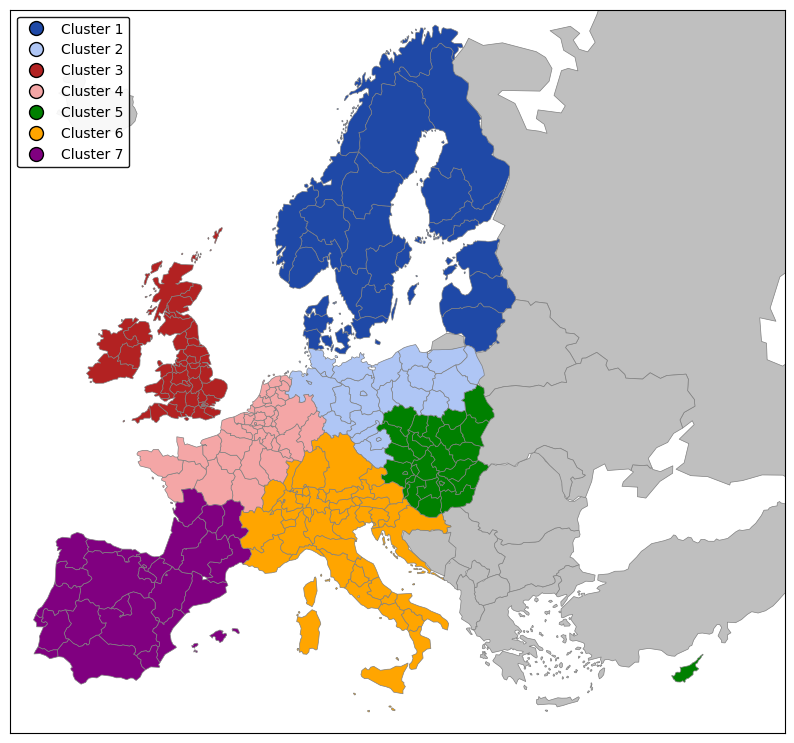


SILHOUETTE SCORES

k = 2: 0.344
k = 3: 0.359
k = 4: 0.425
k = 5: 0.444
k = 6: 0.446
k = 7: 0.460
k = 8: 0.462
k = 9: 0.448
k = 10: 0.449
k = 11: 0.430
k = 12: 0.437
k = 13: 0.438
k = 14: 0.435
k = 15: 0.443

AVERAGE COEFFICIENTS PER CLUSTER

           GDP_cap  COMP_emp  POP_density    HDD    CDD
Cluster 1    0.164    -0.021       -0.086  1.112  0.255
Cluster 2    0.165    -0.020       -0.084  0.307  0.140
Cluster 3    0.140    -0.071       -0.085  0.568  0.124
Cluster 4    0.149    -0.049       -0.085  0.127  0.095
Cluster 5    0.175    -0.007       -0.083  0.115 -0.001
Cluster 6    0.161    -0.024       -0.085  0.065 -0.060
Cluster 7    0.146    -0.046       -0.087 -0.102 -0.141


In [68]:
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import linear_sum_assignment

# Function to find best k using silhouette score
def choose_k_by_silhouette_hierarchical(
    X,
    range_n_clusters=range(2, 16),
    linkage="ward"
):
    scores = {}

    for k in range_n_clusters:
        hierarchical = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = hierarchical.fit_predict(X)
        scores[k] = silhouette_score(X, labels)

    best_k = max(scores, key=scores.get)

    return best_k, scores


# Hierarchical clustering function
def run_hierarchical_clustering(
    params_df,
    df_crs,
    cluster_variables,
    n_clusters=None,
    linkage="ward",
    gdf_reference=None,
    id_col="NUTS",
    reference_cluster_col="cluster",
    plot_filename="./plots/clusters/MGWR_hierarchical_clusters_average.png"
):
    os.makedirs("./plots/clusters", exist_ok=True)

    params_df = params_df.copy()

    # Scale selected coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(params_df[cluster_variables])

    # Choose k if not provided
    if n_clusters is None:
        n_clusters, silhouette_scores = choose_k_by_silhouette_hierarchical(
            X_scaled,
            linkage=linkage
        )
    else:
        alternative_n_clusters, silhouette_scores = choose_k_by_silhouette_hierarchical(
            X_scaled,
            linkage=linkage
        )
        #silhouette_scores = None

    # Run hierarchical clustering
    hierarchical = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )

    params_df["cluster_raw"] = hierarchical.fit_predict(X_scaled)

    # Convert to GeoDataFrame
    gdf_cluster = gpd.GeoDataFrame(
        params_df,
        geometry="geometry",
        crs=df_crs
    )

    
    # If a reference clustering is provided, align hierarchical cluster labels to the reference, e.g. KMeans.
    if gdf_reference is not None:

        ref = gdf_reference[[id_col, reference_cluster_col]].copy()
        tar = gdf_cluster[[id_col, "cluster_raw"]].copy()

        ref = ref.rename(columns={reference_cluster_col: "cluster_reference"})
        tar = tar.rename(columns={"cluster_raw": "cluster_target"})

        merged = ref.merge(
            tar,
            on=id_col,
            how="inner"
        )

        contingency = pd.crosstab(
            merged["cluster_target"],
            merged["cluster_reference"]
        )

        row_ind, col_ind = linear_sum_assignment(-contingency.values)

        target_labels = contingency.index.to_numpy()
        reference_labels = contingency.columns.to_numpy()

        cluster_relabel_map = {
            target_labels[row]: reference_labels[col]
            for row, col in zip(row_ind, col_ind)
        }

        gdf_cluster["cluster"] = (
            gdf_cluster["cluster_raw"]
            .map(cluster_relabel_map)
        )

        # Safety check in case some target clusters were not matched
        if gdf_cluster["cluster"].isna().any():
            missing_clusters = (
                gdf_cluster
                .loc[gdf_cluster["cluster"].isna(), "cluster_raw"]
                .unique()
            )

            raise ValueError(
                f"Some hierarchical clusters could not be matched: {missing_clusters}"
            )

    else:
        # Reorder clusters by north-south position
        gdf_order = gdf_cluster.copy()

        gdf_order["northing"] = gdf_order.geometry.centroid.y

        cluster_north_rank = (
            gdf_order
            .groupby("cluster_raw")["northing"]
            .max()
            .sort_values(ascending=False)
        )

        cluster_relabel_map = {
            old_cluster: new_cluster
            for new_cluster, old_cluster in enumerate(cluster_north_rank.index)
        }

        gdf_cluster["cluster"] = (
            gdf_cluster["cluster_raw"]
            .map(cluster_relabel_map)
        )

    # Assign colors consistently with reordered or aligned clusters
    cluster_colors = [
        "#1F49A7", "#AFC6F5", "#B22222",
        "#F4A6A6", "green", "orange", "purple", "black"
    ]

    if n_clusters > len(cluster_colors):
        raise ValueError(
            f"n_clusters = {n_clusters}, but only {len(cluster_colors)} colors are defined."
        )

    color_map = {
        cluster: cluster_colors[cluster]
        for cluster in sorted(gdf_cluster["cluster"].unique())
    }

    gdf_cluster["color"] = gdf_cluster["cluster"].map(color_map)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))

    background_gdf.plot(
        ax=ax,
        color="#BFBFBF",
        linewidth=0.5,
        edgecolor="0.5"
    )

    gdf_cluster.plot(
        ax=ax,
        color=gdf_cluster["color"],
        linewidth=0.5,
        edgecolor="0.5"
    )

    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=color_map[cluster],
            markeredgecolor="black",
            label=f"Cluster {cluster + 1}",
            markersize=10
        )
        for cluster in sorted(gdf_cluster["cluster"].unique())
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper left",
        frameon=True,
        facecolor="white",
        framealpha=0.9,
        edgecolor="black"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(2500000, 7000000)
    ax.set_ylim(1300000, 5500000)
    ax.ticklabel_format(style="plain", axis="both")

    plt.savefig(plot_filename, dpi=300, bbox_inches="tight")
    plt.show()

    # Summary using aligned clusters
    cluster_summary = (
        gdf_cluster
        .groupby("cluster")[cluster_variables]
        .mean()
    )

    cluster_summary.index = [
        f"Cluster {i + 1}"
        for i in cluster_summary.index
    ]

    # Print results
    if silhouette_scores is not None:
        print("\nSILHOUETTE SCORES\n")
        for k, score in silhouette_scores.items():
            print(f"k = {k}: {score:.3f}")

    print("\nAVERAGE COEFFICIENTS PER CLUSTER\n")
    print(cluster_summary.round(3))


    return gdf_cluster, cluster_summary, silhouette_scores, hierarchical

gdf_cluster_hierarchical, cluster_summary_hierarchical, silhouette_scores_hierarchical, hierarchical = run_hierarchical_clustering(
    params_df=params_avg,
    df_crs=df_by_year[2021].crs,
    cluster_variables=cluster_variables,
    n_clusters=7, # None
    linkage="ward",
    gdf_reference=gdf_KMeans_cluster,
    id_col="NUTS",
    reference_cluster_col="cluster",
    plot_filename="./plots/clusters/MGWR_hierarchical_clusters_average.png"
)

## KMeans vs Hierarchical clustering

In [71]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score


def compare_cluster_solutions(
    gdf_kmeans,
    gdf_hierarchical,
    id_col="NUTS",
    cluster_col="cluster"
):
    
    km = gdf_kmeans[[id_col, cluster_col]].copy()
    hc = gdf_hierarchical[[id_col, cluster_col]].copy()

    km = km.rename(columns={cluster_col: "cluster_kmeans"})
    hc = hc.rename(columns={cluster_col: "cluster_hierarchical"})

    # Merge
    comparison_df = km.merge(
        hc,
        on=id_col,
        how="inner"
    )

    # Compute similarity metrics
    ari = adjusted_rand_score(
        comparison_df["cluster_kmeans"],
        comparison_df["cluster_hierarchical"]
    )

    nmi = normalized_mutual_info_score(
        comparison_df["cluster_kmeans"],
        comparison_df["cluster_hierarchical"]
    )

    # Contingency table
    contingency_table = pd.crosstab(
        comparison_df["cluster_kmeans"] + 1,
        comparison_df["cluster_hierarchical"] + 1,
        rownames=["KMeans cluster"],
        colnames=["Hierarchical cluster"]
    )

    print("\nCLUSTER SIMILARITY METRICS\n")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")

    #print("\nCONTINGENCY TABLE\n")
    #print(contingency_table)

    return comparison_df, contingency_table, ari, nmi

comparison_df, contingency_table, ari, nmi = compare_cluster_solutions(
    gdf_kmeans=gdf_KMeans_cluster,
    gdf_hierarchical=gdf_cluster_hierarchical,
    id_col="NUTS",
    cluster_col="cluster"
)


CLUSTER SIMILARITY METRICS

Adjusted Rand Index: 0.830
Normalized Mutual Information: 0.846
